# Loading library

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('IPL.csv')
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [3]:
df.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'margin', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure'],
      dtype='object')

# Basic information
<pre>Check the size of rows and columns</pre>

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

<pre>Check no of null value</pre>

In [5]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

# Some basic question
<pre>Which team won the most matches/</pre>

In [6]:
df['match_winner'].value_counts()

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Delhi         7
Punjab        7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

In [7]:
maxi=df['match_winner'].value_counts().idxmax()
print(maxi)

Gujarat


In [8]:
most_wins = df['match_winner'].value_counts().max()
print( maxi,most_wins)

Gujarat 12


Text(0.5, 1.0, 'Most match win by Team')

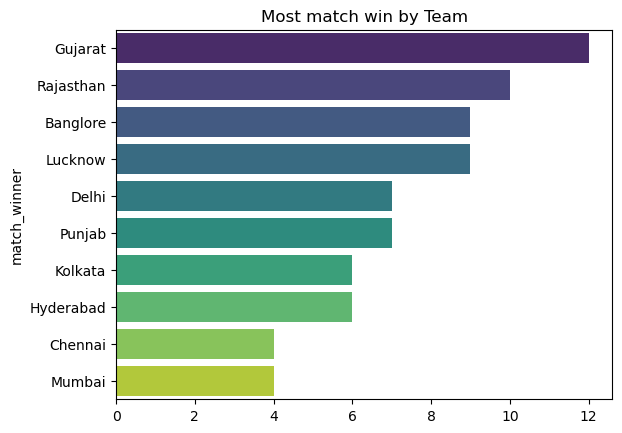

In [9]:
match_wins=df['match_winner'].value_counts()
sns.barplot(y=match_wins.index,x=match_wins.values,palette='viridis')
plt.title('Most match win by Team')

<pre>Toss Decision trend</pre>

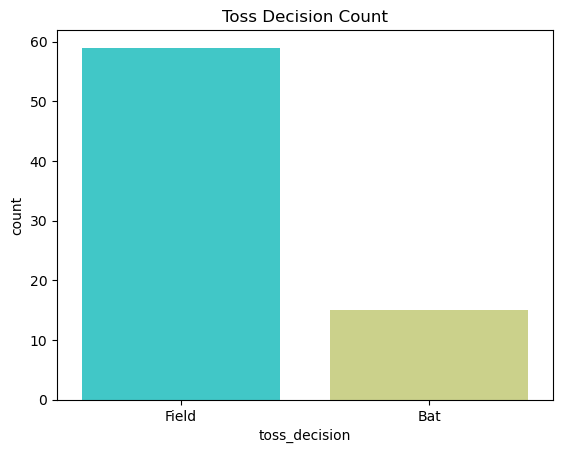

In [10]:
sns.countplot(x='toss_decision', data=df, palette='rainbow')
plt.title("Toss Decision Count")
plt.show()

<pre>Toss winner VS Match Winner</pre>

In [11]:
c=df[df['toss_winner'] == df['match_winner']]['match_id'].count()
percent=(c*100)/df.shape[0]
percent.round(2)

48.65

<pre>how do team win(Run or wicket)</pre>

<Axes: xlabel='won_by', ylabel='count'>

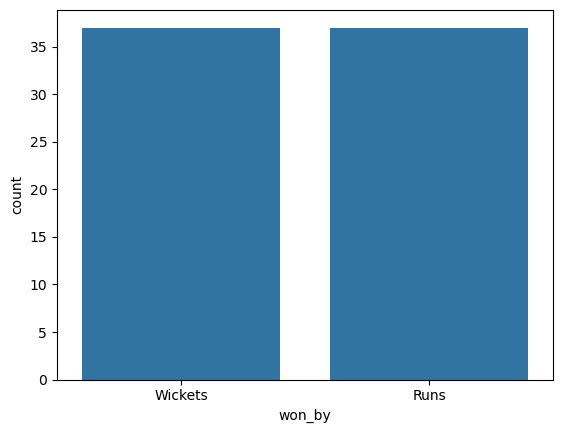

In [12]:
sns.countplot(x=df['won_by'])

# key player performance
<pre>most 'player of the match' awards</pre>

In [17]:
count=df['player_of_the_match'].value_counts().head(10)
count

player_of_the_match
Kuldeep Yadav      4
Jos Buttler        3
Umesh Yadav        2
Quinton de Kock    2
David Miller       2
Umran Malik        2
K L Rahul          2
Rahul Tripathi     2
Hardik Pandya      2
Jasprit Bumrah     2
Name: count, dtype: int64

<Axes: ylabel='player_of_the_match'>

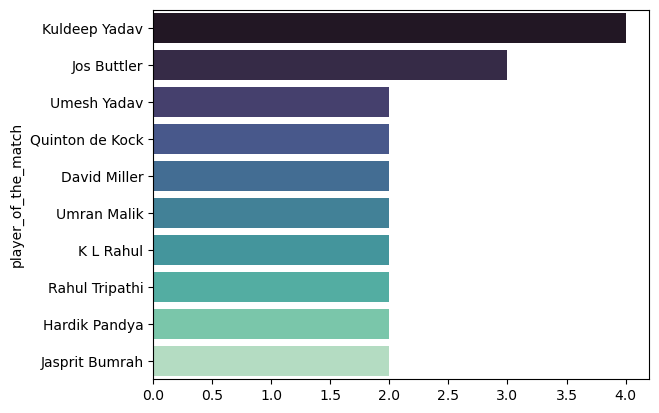

In [20]:
sns.barplot(x=count.values,y=count.index,palette='mako')

<pre>Top 2 scorers</pre>

In [31]:
high=df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
high

top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

<Axes: ylabel='top_scorer'>

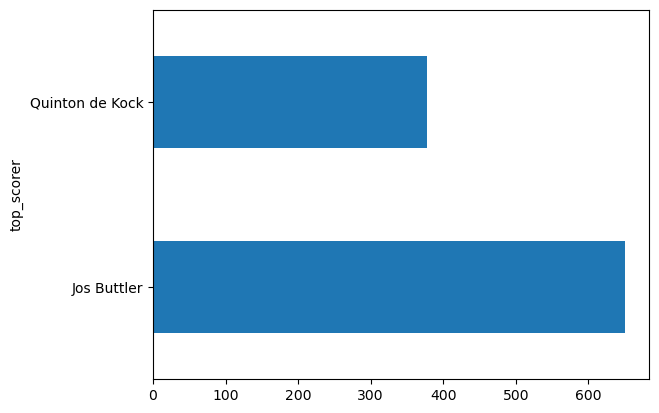

In [32]:
high.plot(kind='barh')

<pre>10 best bowling figures</pre>

In [42]:
df['highest_wicket']=df['best_bowling_figure'].apply(lambda x:x.split('--')[0])
df['highest_wicket']=df['highest_wicket'].astype(int)
top_bowler=df.groupby('best_bowling')['highest_wicket'].sum().sort_values(ascending=False)
top_bowler

best_bowling
Yuzvendra Chahal      17
Kuldeep Yadav         11
Rashid Khan           11
Jasprit Bumrah        11
Avesh Khan            10
Josh Hazlewood        10
Kagiso Rabada         10
Wanindu Hasaranga      9
Umran Malik            9
T Natarajan            8
Maheesh Theekshana     7
Lockie Ferguson        7
Andre Russell          7
Mohsin Khan            7
Daniel Sams            7
Dwayne Bravo           6
Prasidh Krishna        6
Harshal Patel          6
Mohammed Shami         5
Umesh Yadav            4
Hardik Pandya          4
Mukesh Choudhary       4
Odean Smith            4
Shardul Takur          4
Ravi Bishnoi           4
Kuldeep Sen            4
Harpreet Brar          3
Moeen Ali              3
Khaleel Ahmed          3
Ramandeep Singh        3
Rahul Chahar           3
Krunal Pandya          3
Prashant Solanki       2
Rilley Meredith        2
Pradeep Sangwan        2
Murugan Ashwin         2
Tim Southee            2
Trent Boult            2
Mohammed Siraj         2
Chetan Sakar

The best bowling figure is 5--10 by Jasprit Bumrah.


# Venue analysis
<pre>most match played by venue</pre>

In [52]:
vc=df['venue'].value_counts()
vc

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

<Axes: ylabel='venue'>

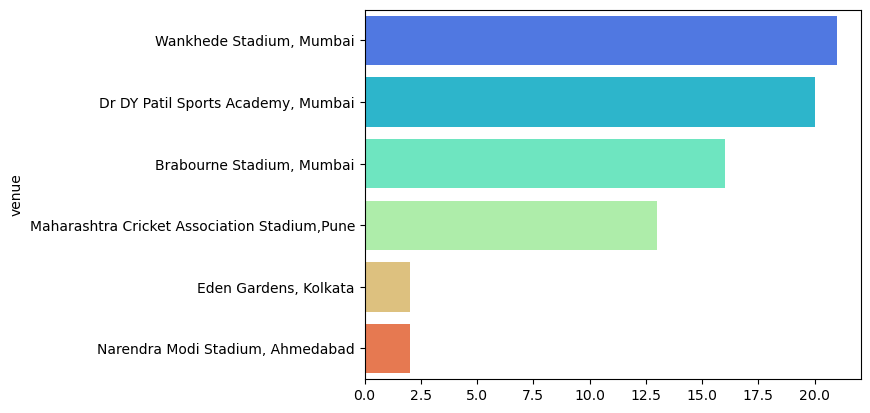

In [54]:
sns.barplot(y=vc.index,x=vc.values,palette='rainbow')

# Custom question
<pre>Who won the highest margin by run</pre>

In [60]:
df[df['won_by']=='Runs'].sort_values(by='margin',ascending=False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


<pre>Which player had the highest individual score</pre>

In [67]:
idx = df['highscore'].idxmax()
player = df.loc[idx, 'top_scorer']
score = df.loc[idx, 'highscore']

print(f"The highest individual score is {score} by {player}.")

The highest individual score is 140 by Quinton de Kock.


<pre>Best Bowling figure</pre>

In [68]:
temp = df['best_bowling_figure'].str.split('--', expand=True)
temp[0] = temp[0].astype(int)  
temp[1] = temp[1].astype(int) 
# Find the index of best bowling: max wickets, min runs
best_index = temp.sort_values([0, 1], ascending=[False, True]).index[0]

# Extract bowler name and figure
bowler_name = df.loc[best_index, 'best_bowling']
bowling_fig = df.loc[best_index, 'best_bowling_figure']

print(f"The best bowling figure is {bowling_fig} by {bowler_name}.")

The best bowling figure is 5--10 by Jasprit Bumrah.
